In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statannotations.Annotator import Annotator

# Color Palette
Colorblindness friendliness was checked on David Nichols' [Coloring for Colorblindness Web Page](https://davidmathlogic.com/colorblind/#%23648FFF-%23785EF0-%23DC267F-%23FE6100-%23FFB000).

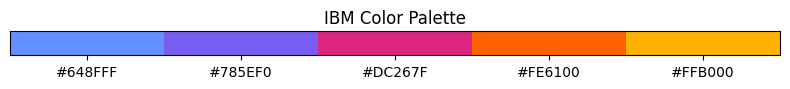

In [3]:
ibm_colors = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000",
]

rgb_colors = [mcolors.to_rgba(c) for c in ibm_colors]

fig, ax = plt.subplots(figsize=(8, 1))

for i, color in enumerate(ibm_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))

ax.set_xlim(0, len(ibm_colors))
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(len(ibm_colors)) + 0.5)
ax.set_xticklabels(ibm_colors, ha="center")

ax.set_yticks([])

ax.set_title("IBM Color Palette")

plt.tight_layout()
plt.show()

mycolors = [rgb_colors[0], rgb_colors[2], rgb_colors[4]]

# Load data

In [4]:
figs_root = Path("../figures/adpkd-exploration-screen").resolve().absolute()
if not figs_root.exists():
    figs_root.mkdir(parents=True)

datapath = (
    Path() / "../data/compound_exploration/ADPKD-CpdExplorationScreen_Batch4042_and_Batch4064.csv"
).resolve()

df = pd.read_csv(datapath)

plate_mapping = {"4042_1": 1, "4042_2": 2, "4064_1": 3}
strip_columns = {c: c.replace("plate.layout.info.", "") for c in df.columns if "plate.layout.info." in c}

df = df.assign(plate_id=lambda x: x["ID"].map(plate_mapping)).drop(columns=["ID", "batch.code"])
df = (
    df.rename(columns=strip_columns)
    .rename(columns={"Type": "treatment_type"})
    .drop(columns=["Stimulation solvent", "Treatment solvent", "Treatment 2 solvent"])  # it's all DMSO
)
df.head(1)

,well.name,treatment_type,Stimulant,Stimulant dose,Stimulant unit,Treatment,Treatment concentration,Treatment unit,Treatment 2,Treatment 2 concentration,Treatment 2 unit,obj.Mean(area).um2.meas,obj.Mean(area).meas.npi_plate,Fraction_dead_cells,increase_death_cells_pct,obj.count_corrected.meas,plate_id
0,C03,ref_ctrl,FSK,2.5,uM,rapamycin,0.03,uM,DMSO,0.1,pct,2173.914,37.281319,0.199,-0.95,865,1


## Normalization

In [5]:
readout = "obj.Mean(area).um2.meas"
method = "median"
norm_array = []

for plate in df.plate_id.unique():
    plate_subset = df.query(f"plate_id == {plate}")
    if method == "mean":
        mean_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .mean()
            .reset_index()
        )
        solv_control = mean_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = mean_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[readout].item()

    if method == "median":
        median_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .median()
            .reset_index()
        )
        solv_control = median_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = median_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[
            readout
        ].item()

    denominator = solv_control - stim_control
    val_array = (
        plate_subset[readout]
        .apply(lambda x: x * -1)
        .add(solv_control)
        .div(denominator)
        .apply(lambda x: x * 100)
    )
    norm_array.extend(val_array.tolist())

df["obj.Mean(area).um2.meas_norm"] = norm_array

# Mann-Whitney U test - Boxplots

## Function definition

In [6]:
def get_significance_symbol(pvalue):
    """
      Converts a p-value to a significance symbol.

      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04
    """
    if pvalue > 0.05:
        return "ns"
    elif pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    else:
        return ""


def plot_single_plate(
    compounds, plate_number, double_treat_cpd, plot_normalized=True, savefig=True, figs_root=None, target=None
):
    target_str = f"-{target}" if target is not None else ""
    spheresize_col = f"obj.Mean(area).um2.meas{'_norm' if plot_normalized else ''}"
    subset = df.query(f"plate_id == {plate_number}")

    idxs = subset.loc[
        (subset["treatment_type"].isin(["solvent_ctrl", "stim_only"])) & (subset["Stimulant"] == "FSK")
    ].index.tolist()
    subset.loc[idxs, "Treatment"] = subset.loc[idxs, "Stimulant"]
    subset.loc[idxs, "Treatment concentration"] = 2.5
    subset.loc[idxs, "Treatment unit"] = "uM"

    subset = subset.assign(
        treat_string=lambda x: x["Treatment"]
        + x["Treatment concentration"].astype(str)
        + " "
        + x["Treatment 2"]
        + x["Treatment 2 concentration"].astype(str)
    ).assign(
        treat_string=lambda x: (
            x["treat_string"]
            .str.replace("DMSO0.1 DMSO0.1", "DMSO 0.2%", regex=False)  # two doses of DMSO 0.1%
            .str.replace("FSK2.5 DMSO0.1", "FSK 2.5µM", regex=False)
            .str.replace("DMSO0.1", "", regex=False)
            .str.replace("0.001", " 0.001µM", regex=False)
            .str.replace("1.0", " 1µM", regex=False)
            .str.replace("0.1 ", " 0.1µM ", regex=False)
            .str.rstrip()
        )
    )
    short_dict = {  # dictionary to abbreviate compound names
        "Aldosterone": "ALD",
        "Esaxerenone": "Esax",
        "Finerenone": "Fin",
        "Capadenoson": "Capa",
        "Benidipine": "Beni",
        "Apararenone": "Apa",
    }

    all_stats_results = []  # to store all the statistical results
    for cpd in compounds:
        short_cpd = short_dict.get(cpd, cpd)
        subset_controls = subset.query("treatment_type.isin(['solvent_ctrl', 'stim_only'])")
        subset_controls["Treatment 2"] = "Control"

        subset_cpd = subset.query(f"Treatment == '{cpd}'")
        subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
            lambda x: 0 if x == "DMSO" else 1
        )
        subset_cpd = subset_cpd.sort_values(["Treatment 2 Sort Key", "Treatment concentration"]).drop(
            columns=["Treatment 2 Sort Key"]
        )

        fig, ax = plt.subplots(figsize=(4, 3.6))
        plot_data = pd.concat([subset_controls, subset_cpd])
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: "+ FSK 2.5µM" if x == "DMSO" else x
        )
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: f"+ {x} + FSK 2.5 µM" if x not in ["Control", "+ FSK 2.5µM"] else x
        )

        def update_treatment_2(row, double_treat_cpd):
            """Add the concentration of the double treatment!! This is for the legend only"""
            return row["Treatment 2"].replace(
                double_treat_cpd, f"{double_treat_cpd} {row['Treatment 2 concentration']}µM"
            )

        doubletreat_search_pattern = re.compile(f"(?=.{cpd})|(?=.{double_treat_cpd})")
        mask = plot_data.treat_string.str.contains(doubletreat_search_pattern, regex=True)
        plot_data.loc[mask, "Treatment 2"] = plot_data.loc[mask].apply(
            update_treatment_2, double_treat_cpd=double_treat_cpd, axis=1
        )

        sns.boxplot(
            data=plot_data,
            x="treat_string",
            y=spheresize_col,
        )

        labels = (
            plot_data[["treat_string", "Treatment 2"]]
            .drop_duplicates()["Treatment 2"]
            .str.replace("Aldosterone", "ALD")
            .str.replace(" + FSK ", "\n+ FSK ")
        )
        uniq_labels = labels.drop_duplicates().tolist()
        # uniq_colors = sns.color_palette("tab10", n_colors=3)
        uniq_colors = mycolors
        colors = [uniq_colors[0]] * 2 + [uniq_colors[1]] * 3 + [uniq_colors[2]] * 3

        legend_handles = [
            mpatches.Patch(facecolor=color, label=label, edgecolor="black", linewidth=0.5)
            for label, color in zip(uniq_labels, uniq_colors)
        ]

        bars = ax.patches
        for bar, color in zip(bars, colors):
            bar.set_facecolor(color)

        ax.legend(
            handles=legend_handles, bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False
        )

        # Prepare pairs for statistical annotation
        control_condition = "FSK 2.5µM"
        treatment_conditions = [f"{cpd} 0.001µM", f"{cpd} 0.1µM", f"{cpd} 1µM"]
        # 1. add the comparisons of the stimulant control (+FSK) with all treatment conditions
        pairs = [(control_condition, cond) for cond in treatment_conditions] + [
            (f"{cpd} 0.001µM {double_treat_cpd} 1µM", f"{cpd} 1µM {double_treat_cpd} 1µM"),
            (f"{cpd} 0.001µM {double_treat_cpd} 1µM", f"{cpd} 0.1µM {double_treat_cpd} 1µM"),
        ]
        # 2. add comparisons of different concentrations of the treatment conditions
        pairs.extend(  # E.g.: treatment (T) 0.001µM vs T 0.1µM, T 0.1µM vs T 1.0µM
            [(treatment_conditions[i], treatment_conditions[j]) for i in range(3) for j in range(i + 1, 3)]
        )
        print(pairs)

        # Add statistical annotations
        annotator = Annotator(ax, pairs, data=plot_data, x="treat_string", y=spheresize_col)
        annotator.configure(
            test="Mann-Whitney",
            text_format="star",
            loc="inside",
            hide_non_significant=True,
        )
        _, annotations = annotator.apply_and_annotate()
        labels = [tick.get_text() for tick in ax.get_xticklabels()]
        # get rid of the + doublee_treat_cpd <concentration> part of the string (already in the legend)
        # new_labels = [re.sub(double_treat_cpd + r"\s\d\.?\d*\s?µM", "", x) for x in labels]
        new_labels = labels[:5] + [
            " ".join([*lab.split()[:2], "+", *lab.split()[2:-1]]) for lab in labels[5:]
        ]
        if double_treat_cpd == "Aldosterone":
            new_labels = [label.replace("Aldosterone", "ALD") for label in new_labels]
        if cpd != short_cpd:
            new_labels = [label.replace(cpd, short_cpd) for label in new_labels]
        ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)

        ax.set_xlabel("")
        ax.set_ylabel(r"Normalized Cyst Swelling (%)")
        target_mapping = {
            "GLU": "GLUT1",
            "P2RX7": "P2X7",
            "A1R": r"$\mathrm{A}_{1}\mathrm{AR}$",
            "MR": "MR",
        }
        ax.set_title(
            f"{cpd}{' (' + short_cpd + ')' if short_cpd != cpd else ''}, "
            f"{target_mapping.get(target, target)}"
        )

        stats_results = []
        for res in annotations:
            stats_results.append(
                {
                    "group1": res.data.group1[0],
                    "group2": res.data.group2[0],
                    "pvalue": res.data.pvalue,
                    "symbol": get_significance_symbol(res.data.pvalue),
                    "test_description": res.data.test_description,
                    "target": target_mapping.get(target, target),
                    "plate_number": plate_number,
                    "compound": cpd,
                    "stimulant_dose": 2.5,
                    "double_treat_cpd": double_treat_cpd,
                }
            )
        stats_df = pd.DataFrame(stats_results)
        all_stats_results.append(stats_df)

        ax.spines[["right", "top"]].set_visible(False)
        ax.grid(axis="y", alpha=0.5)
        ax.set_axisbelow(True)

        if savefig:
            if figs_root is None:
                figs_root = (Path().parent / "figures").resolve().absolute()
            fig.savefig(
                figs_root / f"boxplot-MannWhitneyU-plate{plate_number}{target_str}_{cpd}_FSK2-5.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
            )
            fig.savefig(
                figs_root / f"boxplot-MannWhitneyU-plate{plate_number}{target_str}_{cpd}_FSK2-5.svg",
                bbox_inches="tight",
                facecolor="none",
            )

        plt.show()

    all_stats_results = pd.concat(all_stats_results, ignore_index=True)
    return all_stats_results

## Hold all the statistics results

In [7]:
all_stats_results = []

## ADORA1

### Plate 2

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


[('FSK 2.5µM', 'DPCPX 0.001µM'), ('FSK 2.5µM', 'DPCPX 0.1µM'), ('FSK 2.5µM', 'DPCPX 1µM'), ('DPCPX 0.001µM CPA 1µM', 'DPCPX 1µM CPA 1µM'), ('DPCPX 0.001µM CPA 1µM', 'DPCPX 0.1µM CPA 1µM'), ('DPCPX 0.001µM', 'DPCPX 0.1µM'), ('DPCPX 0.001µM', 'DPCPX 1µM'), ('DPCPX 0.1µM', 'DPCPX 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. DPCPX 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.967e-02 U_stat=6.000e+00
DPCPX 0.001µM CPA 1µM vs. DPCPX 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.319e-02 U_stat=4.000e+00


/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


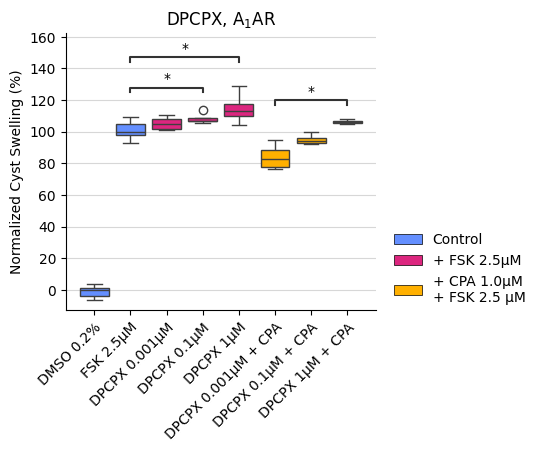

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


[('FSK 2.5µM', 'Capadenoson 0.001µM'), ('FSK 2.5µM', 'Capadenoson 0.1µM'), ('FSK 2.5µM', 'Capadenoson 1µM'), ('Capadenoson 0.001µM CPA 1µM', 'Capadenoson 1µM CPA 1µM'), ('Capadenoson 0.001µM CPA 1µM', 'Capadenoson 0.1µM CPA 1µM'), ('Capadenoson 0.001µM', 'Capadenoson 0.1µM'), ('Capadenoson 0.001µM', 'Capadenoson 1µM'), ('Capadenoson 0.1µM', 'Capadenoson 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Capadenoson 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
Capadenoson 0.001µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
Capadenoson 0.001µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM

/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


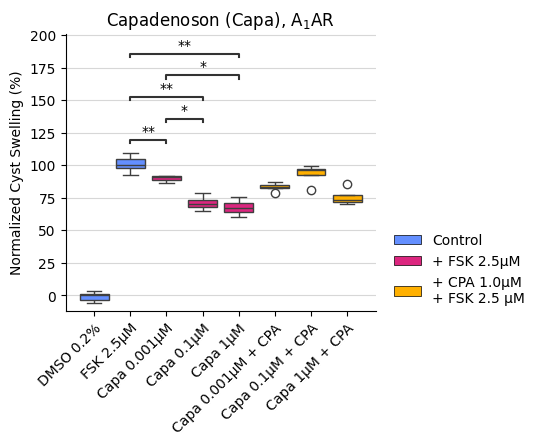

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


[('FSK 2.5µM', 'MIPS521 0.001µM'), ('FSK 2.5µM', 'MIPS521 0.1µM'), ('FSK 2.5µM', 'MIPS521 1µM'), ('MIPS521 0.001µM CPA 1µM', 'MIPS521 1µM CPA 1µM'), ('MIPS521 0.001µM CPA 1µM', 'MIPS521 0.1µM CPA 1µM'), ('MIPS521 0.001µM', 'MIPS521 0.1µM'), ('MIPS521 0.001µM', 'MIPS521 1µM'), ('MIPS521 0.1µM', 'MIPS521 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MIPS521 0.001µM CPA 1µM vs. MIPS521 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
MIPS521 0.001µM vs. MIPS521 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
MIPS521 0.1µM vs. MIPS521 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. MIPS521 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
MIPS521 0.001µM CPA 1µM vs. MIPS521 1µM CPA 1µM: Mann-Whitney-Wilco

/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


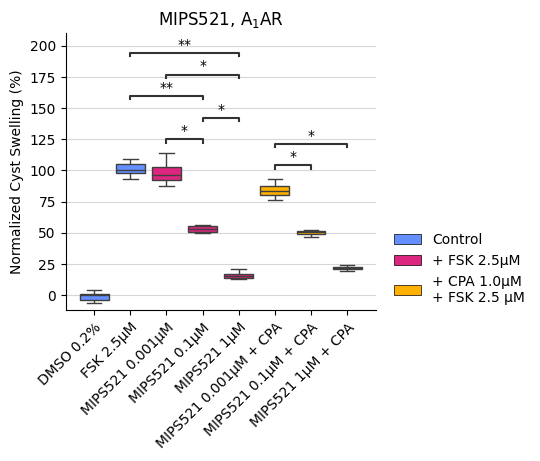

In [8]:
subset = df.query("plate_id == 2")

treatments = [
    "DPCPX",
    "Capadenoson",
    "MIPS521",
]

stats_results = plot_single_plate(treatments, 2, "CPA", figs_root=figs_root, target="A1R")
all_stats_results.append(stats_results)

### Plate 3

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', '824745 0.001µM'), ('FSK 2.5µM', '824745 0.1µM'), ('FSK 2.5µM', '824745 1µM'), ('824745 0.001µM CPA 1µM', '824745 1µM CPA 1µM'), ('824745 0.001µM CPA 1µM', '824745 0.1µM CPA 1µM'), ('824745 0.001µM', '824745 0.1µM'), ('824745 0.001µM', '824745 1µM'), ('824745 0.1µM', '824745 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



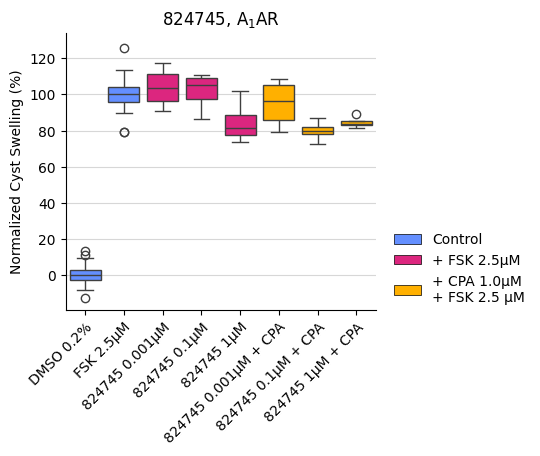

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', '1237561 0.001µM'), ('FSK 2.5µM', '1237561 0.1µM'), ('FSK 2.5µM', '1237561 1µM'), ('1237561 0.001µM CPA 1µM', '1237561 1µM CPA 1µM'), ('1237561 0.001µM CPA 1µM', '1237561 0.1µM CPA 1µM'), ('1237561 0.001µM', '1237561 0.1µM'), ('1237561 0.001µM', '1237561 1µM'), ('1237561 0.1µM', '1237561 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1237561 0.001µM CPA 1µM vs. 1237561 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01


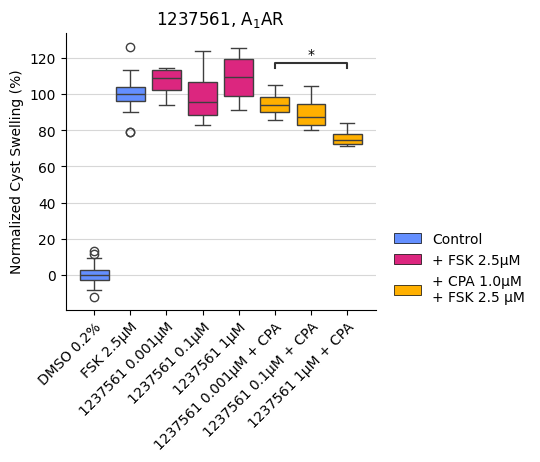

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', '1249141 0.001µM'), ('FSK 2.5µM', '1249141 0.1µM'), ('FSK 2.5µM', '1249141 1µM'), ('1249141 0.001µM CPA 1µM', '1249141 1µM CPA 1µM'), ('1249141 0.001µM CPA 1µM', '1249141 0.1µM CPA 1µM'), ('1249141 0.001µM', '1249141 0.1µM'), ('1249141 0.001µM', '1249141 1µM'), ('1249141 0.1µM', '1249141 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1249141 0.1µM vs. 1249141 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. 1249141 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.890e-03 U_stat=6.100e+01


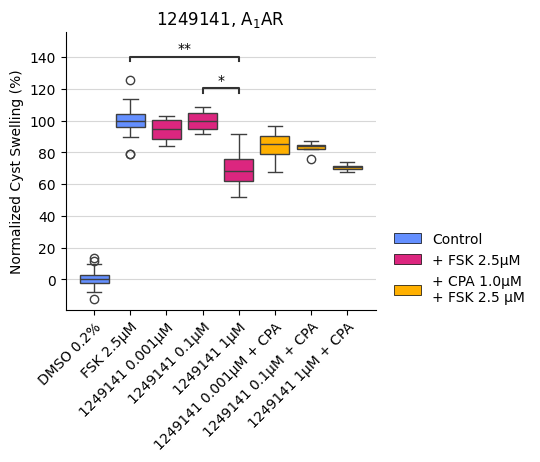

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', '1823372 0.001µM'), ('FSK 2.5µM', '1823372 0.1µM'), ('FSK 2.5µM', '1823372 1µM'), ('1823372 0.001µM CPA 1µM', '1823372 1µM CPA 1µM'), ('1823372 0.001µM CPA 1µM', '1823372 0.1µM CPA 1µM'), ('1823372 0.001µM', '1823372 0.1µM'), ('1823372 0.001µM', '1823372 1µM'), ('1823372 0.1µM', '1823372 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 1823372 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.188e-02 U_stat=8.000e+00


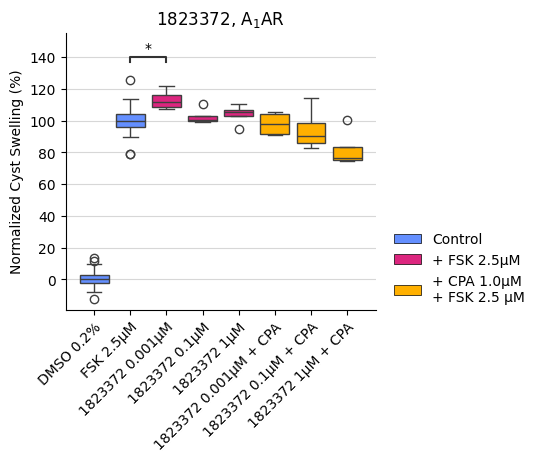

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', '22755240 0.001µM'), ('FSK 2.5µM', '22755240 0.1µM'), ('FSK 2.5µM', '22755240 1µM'), ('22755240 0.001µM CPA 1µM', '22755240 1µM CPA 1µM'), ('22755240 0.001µM CPA 1µM', '22755240 0.1µM CPA 1µM'), ('22755240 0.001µM', '22755240 0.1µM'), ('22755240 0.001µM', '22755240 1µM'), ('22755240 0.1µM', '22755240 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



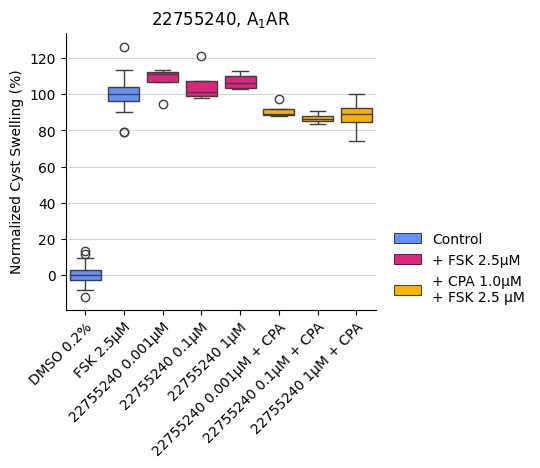

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


[('FSK 2.5µM', '27070328 0.001µM'), ('FSK 2.5µM', '27070328 0.1µM'), ('FSK 2.5µM', '27070328 1µM'), ('27070328 0.001µM CPA 1µM', '27070328 1µM CPA 1µM'), ('27070328 0.001µM CPA 1µM', '27070328 0.1µM CPA 1µM'), ('27070328 0.001µM', '27070328 0.1µM'), ('27070328 0.001µM', '27070328 1µM'), ('27070328 0.1µM', '27070328 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

27070328 0.001µM vs. 27070328 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
27070328 0.1µM vs. 27070328 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
27070328 0.001µM CPA 1µM vs. 27070328 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
27070328 0.001µM vs. 27070328 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. 27070328 1µM: Mann-Whitney-Wil

/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


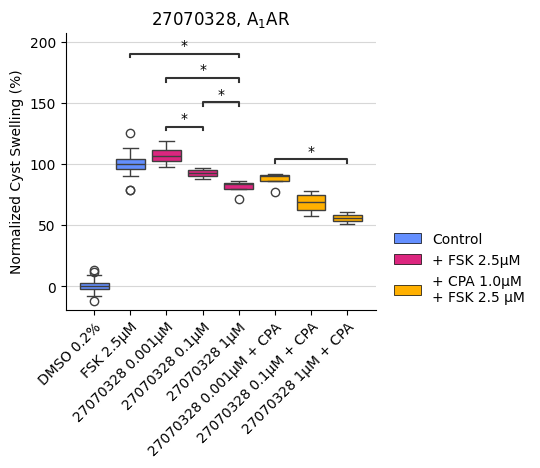

In [9]:
subset = df.query("plate_id == 3")

treatments = ["824745", "1237561", "1249141", "1823372", "22755240", "27070328"]

stats_results = plot_single_plate(treatments, 3, "CPA", figs_root=figs_root, target="A1R")
all_stats_results.append(stats_results)

## NR3C2

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Finerenone 0.001µM'), ('FSK 2.5µM', 'Finerenone 0.1µM'), ('FSK 2.5µM', 'Finerenone 1µM'), ('Finerenone 0.001µM Aldosterone 1µM', 'Finerenone 1µM Aldosterone 1µM'), ('Finerenone 0.001µM Aldosterone 1µM', 'Finerenone 0.1µM Aldosterone 1µM'), ('Finerenone 0.001µM', 'Finerenone 0.1µM'), ('Finerenone 0.001µM', 'Finerenone 1µM'), ('Finerenone 0.1µM', 'Finerenone 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Finerenone 0.001µM Aldosterone 1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.115e-02 U_stat=6.000e+00


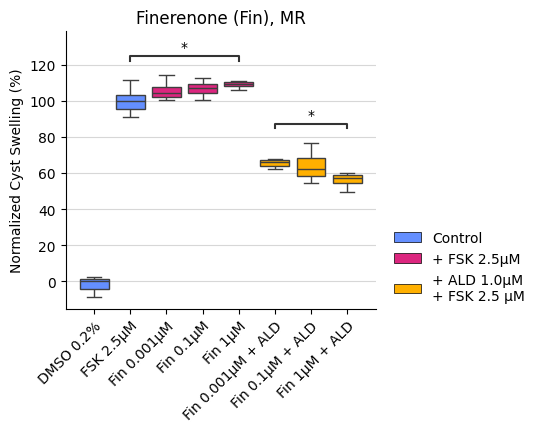

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Esaxerenone 0.001µM'), ('FSK 2.5µM', 'Esaxerenone 0.1µM'), ('FSK 2.5µM', 'Esaxerenone 1µM'), ('Esaxerenone 0.001µM Aldosterone 1µM', 'Esaxerenone 1µM Aldosterone 1µM'), ('Esaxerenone 0.001µM Aldosterone 1µM', 'Esaxerenone 0.1µM Aldosterone 1µM'), ('Esaxerenone 0.001µM', 'Esaxerenone 0.1µM'), ('Esaxerenone 0.001µM', 'Esaxerenone 1µM'), ('Esaxerenone 0.1µM', 'Esaxerenone 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Esaxerenone 0.001µM vs. Esaxerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Esaxerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.931e-02 U_stat=5.500e+01


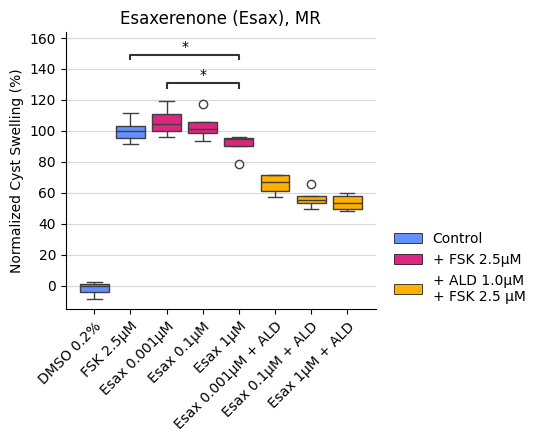

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Apararenone 0.001µM'), ('FSK 2.5µM', 'Apararenone 0.1µM'), ('FSK 2.5µM', 'Apararenone 1µM'), ('Apararenone 0.001µM Aldosterone 1µM', 'Apararenone 1µM Aldosterone 1µM'), ('Apararenone 0.001µM Aldosterone 1µM', 'Apararenone 0.1µM Aldosterone 1µM'), ('Apararenone 0.001µM', 'Apararenone 0.1µM'), ('Apararenone 0.001µM', 'Apararenone 1µM'), ('Apararenone 0.1µM', 'Apararenone 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



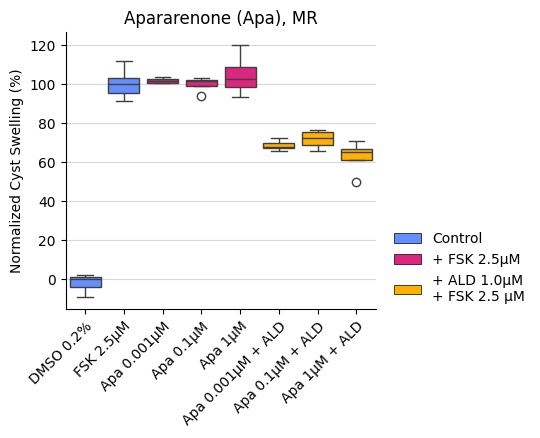

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Benidipine 0.001µM'), ('FSK 2.5µM', 'Benidipine 0.1µM'), ('FSK 2.5µM', 'Benidipine 1µM'), ('Benidipine 0.001µM Aldosterone 1µM', 'Benidipine 1µM Aldosterone 1µM'), ('Benidipine 0.001µM Aldosterone 1µM', 'Benidipine 0.1µM Aldosterone 1µM'), ('Benidipine 0.001µM', 'Benidipine 0.1µM'), ('Benidipine 0.001µM', 'Benidipine 1µM'), ('Benidipine 0.1µM', 'Benidipine 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



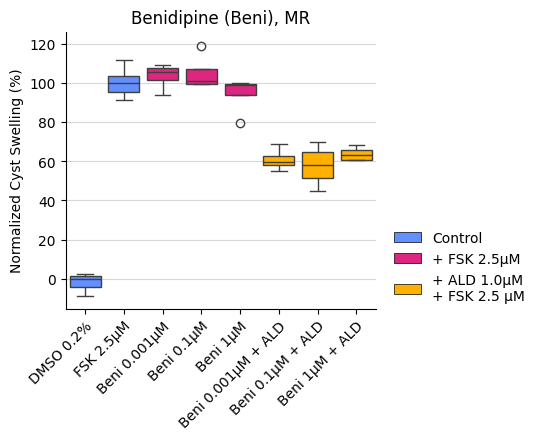

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Z318400112 0.001µM'), ('FSK 2.5µM', 'Z318400112 0.1µM'), ('FSK 2.5µM', 'Z318400112 1µM'), ('Z318400112 0.001µM Aldosterone 1µM', 'Z318400112 1µM Aldosterone 1µM'), ('Z318400112 0.001µM Aldosterone 1µM', 'Z318400112 0.1µM Aldosterone 1µM'), ('Z318400112 0.001µM', 'Z318400112 0.1µM'), ('Z318400112 0.001µM', 'Z318400112 1µM'), ('Z318400112 0.1µM', 'Z318400112 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Z318400112 0.001µM Aldosterone 1µM vs. Z318400112 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00


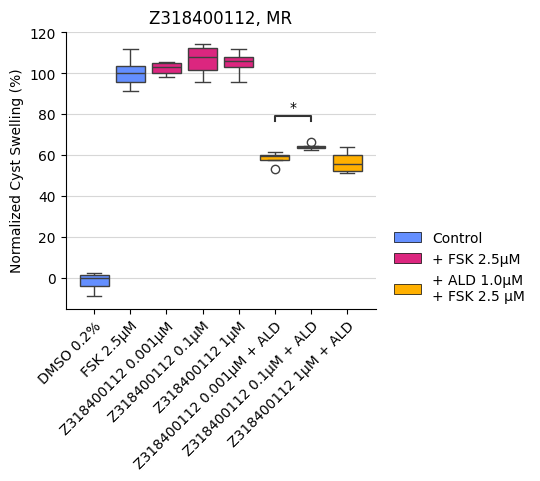

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right

[('FSK 2.5µM', 'Z90308949 0.001µM'), ('FSK 2.5µM', 'Z90308949 0.1µM'), ('FSK 2.5µM', 'Z90308949 1µM'), ('Z90308949 0.001µM Aldosterone 1µM', 'Z90308949 1µM Aldosterone 1µM'), ('Z90308949 0.001µM Aldosterone 1µM', 'Z90308949 0.1µM Aldosterone 1µM'), ('Z90308949 0.001µM', 'Z90308949 0.1µM'), ('Z90308949 0.001µM', 'Z90308949 1µM'), ('Z90308949 0.1µM', 'Z90308949 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



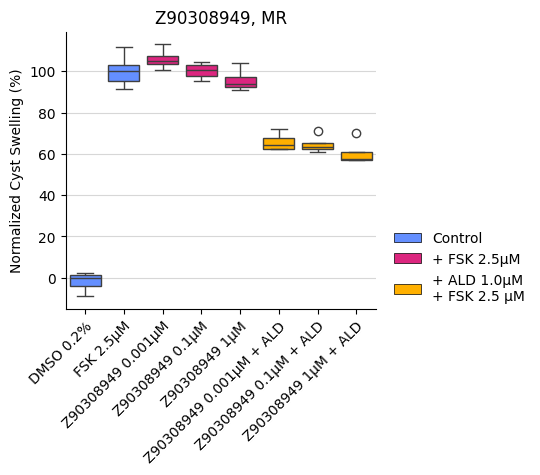

/tmp/ipykernel_4138152/3802382140.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_4138152/3802382140.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


[('FSK 2.5µM', 'Z95680027 0.001µM'), ('FSK 2.5µM', 'Z95680027 0.1µM'), ('FSK 2.5µM', 'Z95680027 1µM'), ('Z95680027 0.001µM Aldosterone 1µM', 'Z95680027 1µM Aldosterone 1µM'), ('Z95680027 0.001µM Aldosterone 1µM', 'Z95680027 0.1µM Aldosterone 1µM'), ('Z95680027 0.001µM', 'Z95680027 0.1µM'), ('Z95680027 0.001µM', 'Z95680027 1µM'), ('Z95680027 0.1µM', 'Z95680027 1µM')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Z95680027 0.001µM Aldosterone 1µM vs. Z95680027 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
Z95680027 0.1µM vs. Z95680027 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
Z95680027 0.001µM Aldosterone 1µM vs. Z95680027 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
Z95680027 0.001µM vs. Z95680027 1µM: Mann-Whitney-W

/tmp/ipykernel_4138152/3802382140.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


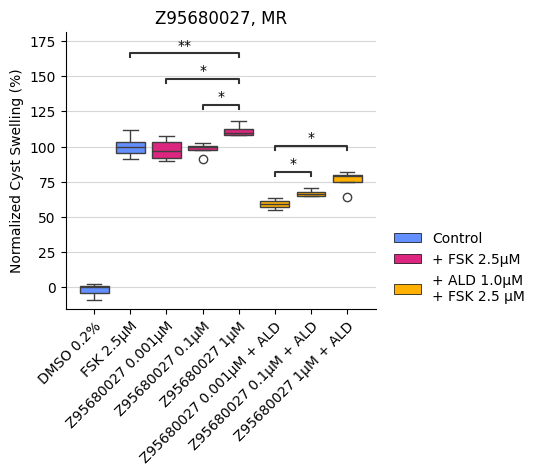

In [10]:
treatments = [
    "Finerenone",
    "Esaxerenone",
    "Apararenone",
    "Benidipine",
    "Z318400112",
    "Z90308949",
    "Z95680027",
]
stats_results = plot_single_plate(treatments, 1, "Aldosterone", figs_root=figs_root, target="MR")
all_stats_results.append(stats_results)

# Stats results for all targets

In [11]:
all_stats_results = pd.concat(all_stats_results, ignore_index=True)

In [12]:
from itertools import product


def to_latex_scientific(value, precision=1):
    """
    Converts a float into a LaTeX-formatted scientific notation string.

    Args:
        value (float or int): The number to convert.
        precision (int): The number of decimal places for the coefficient.

    Returns:
        str: A LaTeX-formatted string.
    """
    if not isinstance(value, (int, float)):
        raise TypeError("Input must be a number.")

    if value == 0:
        return "$0$"

    # Format the number in scientific notation and split it
    formatted_str = f"{value:.{precision}e}"
    mantissa_str, exponent_str = formatted_str.split("e")

    exponent = int(exponent_str)

    # If the exponent is 0, the scientific notation is unnecessary
    if exponent == 0:
        return f"${mantissa_str}$"

    # Clean up the mantissa if it's a whole number (e.g., "5.0" -> "5")
    mantissa_float = float(mantissa_str)
    if precision == 0 and mantissa_float == int(mantissa_float):
        mantissa_str = str(int(mantissa_float))

    # Construct the LaTeX string
    return f"${mantissa_str} \\times 10^{{{exponent}}}$"


compounds = all_stats_results.compound.unique().tolist()
stimulant_dose = all_stats_results.stimulant_dose.unique().tolist()

for cpd, dose in product(compounds, stimulant_dose):
    stats_subset = all_stats_results.query(f"compound == '{cpd}' & stimulant_dose == {dose}")
    if not stats_subset.empty:
        print(f"## {cpd} - Simulant (FSK) dose: {dose}µM")
        print(
            stats_subset.assign(
                pvalue=lambda x: x.pvalue.apply(lambda y: to_latex_scientific(y, precision=2)),
            )
            .drop(columns=["compound", "stimulant_dose", "double_treat_cpd", "plate_number"])
            .to_markdown(index=False)
        )
        print()

## DPCPX - Simulant (FSK) dose: 2.5µM
| group1                | group2              | pvalue                | symbol   | test_description                     | target                      |
|:----------------------|:--------------------|:----------------------|:---------|:-------------------------------------|:----------------------------|
| FSK 2.5µM             | DPCPX 0.001µM       | $2.12 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | $\mathrm{A}_{1}\mathrm{AR}$ |
| DPCPX 0.001µM CPA 1µM | DPCPX 0.1µM CPA 1µM | $1.14 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | $\mathrm{A}_{1}\mathrm{AR}$ |
| DPCPX 0.001µM         | DPCPX 0.1µM         | $6.86 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | $\mathrm{A}_{1}\mathrm{AR}$ |
| DPCPX 0.1µM           | DPCPX 1µM           | $4.86 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | $\mathrm{A}_{1}\mathrm{AR}$ |
| FSK 2.5µM             | DPCPX 0.1µM         | $2

# Cyst Size v.s. Concentration

## Function definition

In [13]:
import sys

sys.path.append("../03_Target_Validation")

from plot_functions import plot_with_curves

## ADORA1

### Plate 2

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(


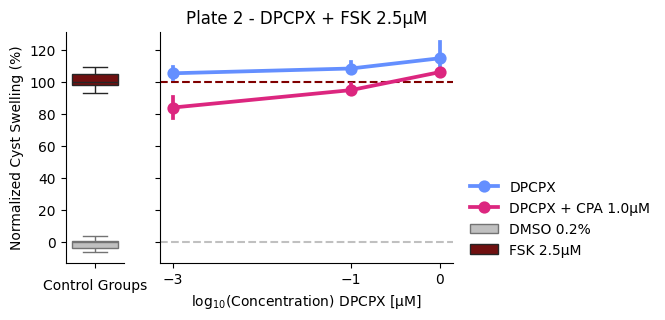

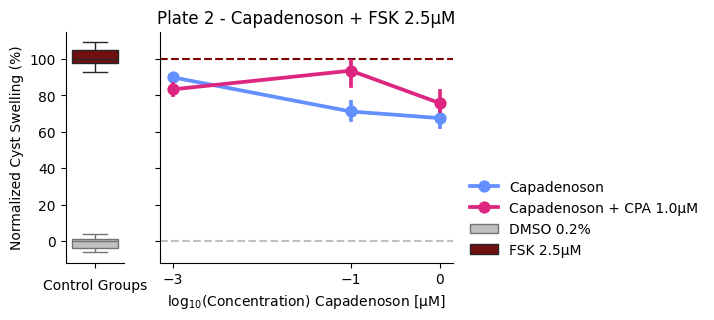

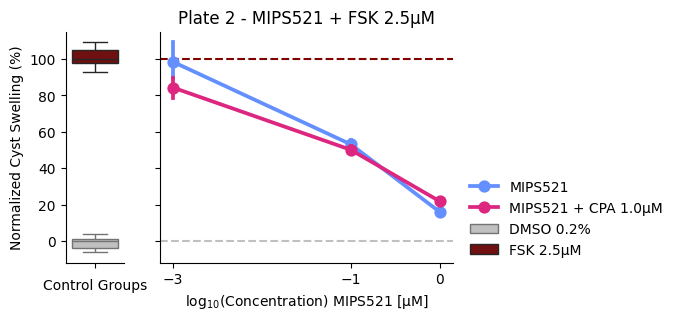

In [14]:
_ = plot_with_curves(df, 2, "DPCPX", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 2, "Capadenoson", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 2, "MIPS521", figs_root=figs_root, target="A1R")

### Plate 3

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-a

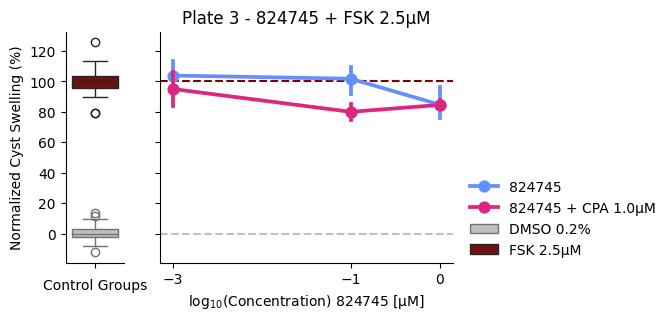

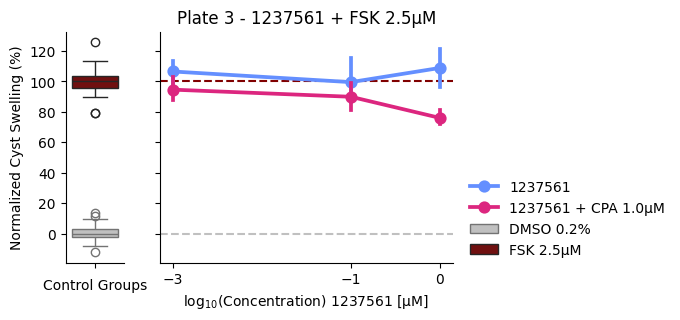

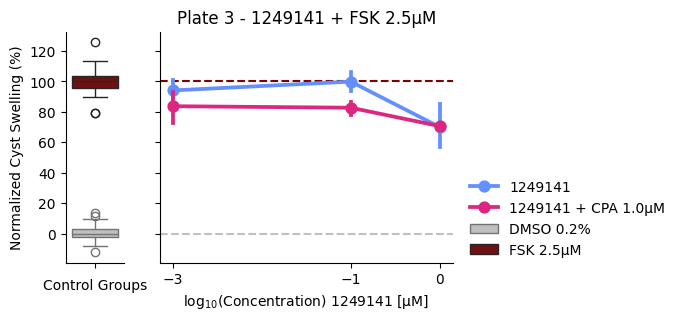

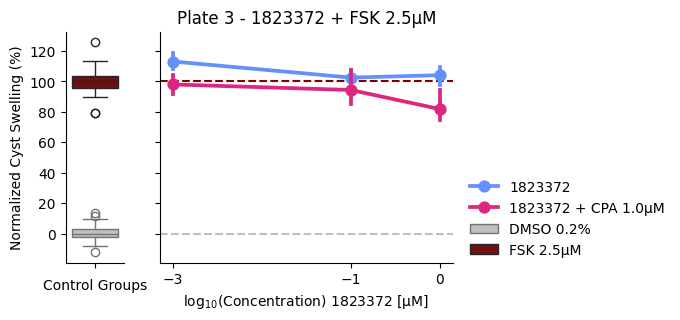

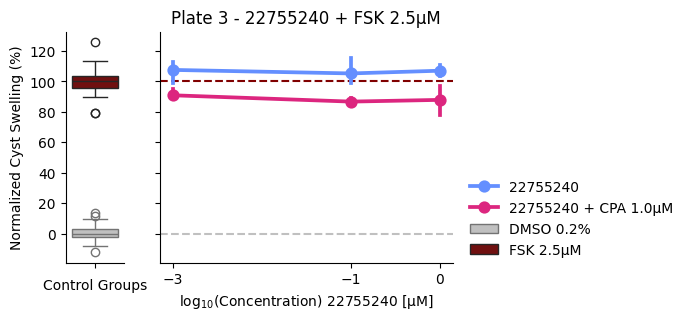

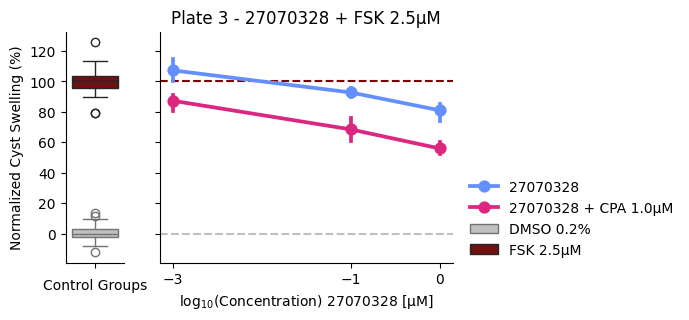

In [15]:
_ = plot_with_curves(df, 3, "824745", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1237561", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1249141", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1823372", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "22755240", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "27070328", figs_root=figs_root, target="A1R")

## NR3C2

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-a

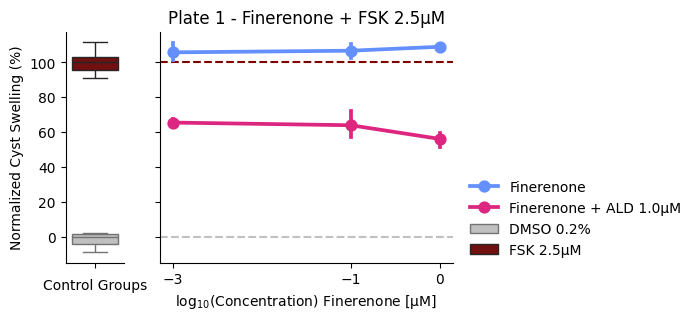

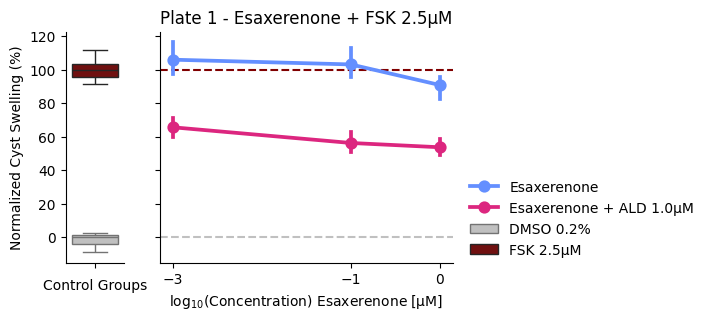

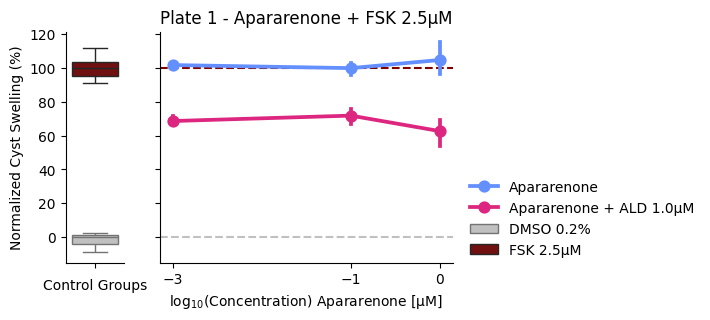

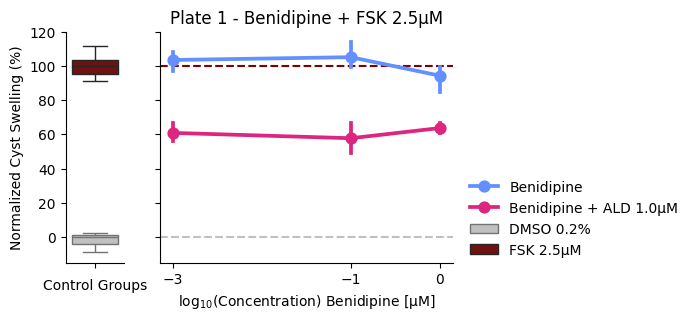

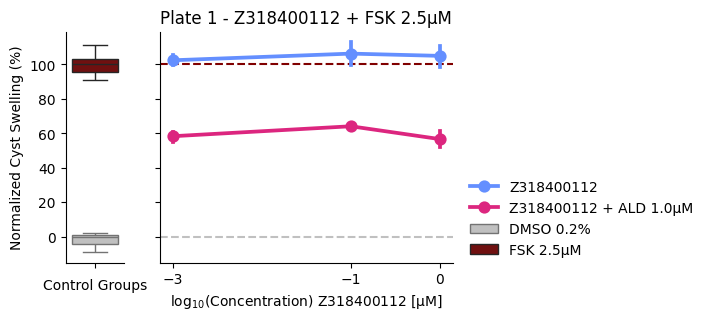

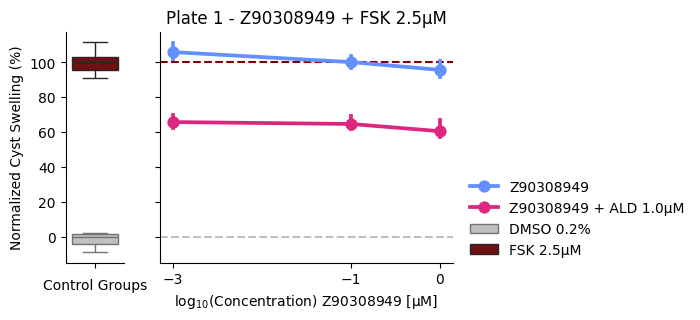

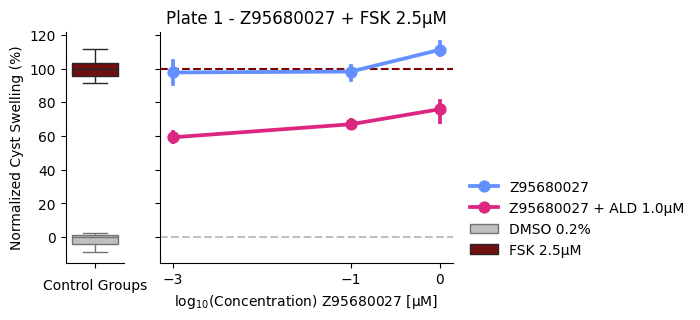

In [16]:
_ = plot_with_curves(df, 1, "Finerenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Esaxerenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Apararenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Benidipine", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z318400112", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z90308949", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z95680027", figs_root=figs_root, target="MR")